import liberaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Download NLTK Stopwords

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nyct_cg/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Load Dataset

In [4]:
df = pd.read_csv("Reviews.csv")

Quick Dataset Inspection

In [5]:
print(df.shape)

df.head()

df.info()

(568454, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


Keeping Only Required Columns

In [6]:
df = df[['Score', 'Text']]

Removing missing Values

In [7]:
df = df.dropna()

Creating Sentiment Labels

In [8]:
def get_sentiment(score):

    if score >= 4:
        return "Positive"

    elif score == 3:
        return "Neutral"

    else:
        return "Negative"

df["Sentiment"] = df["Score"].apply(get_sentiment)

Visualizing Sentiment Distribution

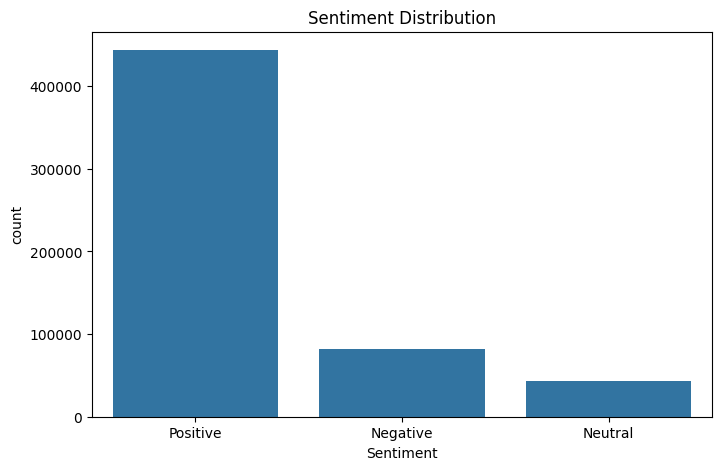

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

Reducing Dataset Size

In [11]:
df = df.sample(
    n=50000,
    random_state=42
)

Text Cleaning

In [12]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["CleanText"] = df["Text"].apply(clean_text)

TF-IDF

In [13]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df["CleanText"]
)

y = df["Sentiment"]

Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model 1: Naive Bayes

In [15]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [16]:
print("Naive Bayes")

print(
    classification_report(
        y_test,
        nb_pred
    )
)

Naive Bayes
              precision    recall  f1-score   support

    Negative       0.84      0.28      0.42      1405
     Neutral       0.67      0.00      0.01       794
    Positive       0.82      1.00      0.90      7801

    accuracy                           0.82     10000
   macro avg       0.78      0.43      0.44     10000
weighted avg       0.81      0.82      0.76     10000



Model 2: Linear SVM

In [17]:
svm = LinearSVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [18]:
print("Linear SVM")

print(
    classification_report(
        y_test,
        svm_pred
    )
)

Linear SVM
              precision    recall  f1-score   support

    Negative       0.72      0.66      0.69      1405
     Neutral       0.52      0.23      0.32       794
    Positive       0.90      0.96      0.93      7801

    accuracy                           0.86     10000
   macro avg       0.71      0.62      0.64     10000
weighted avg       0.84      0.86      0.85     10000



Confusion Matrix

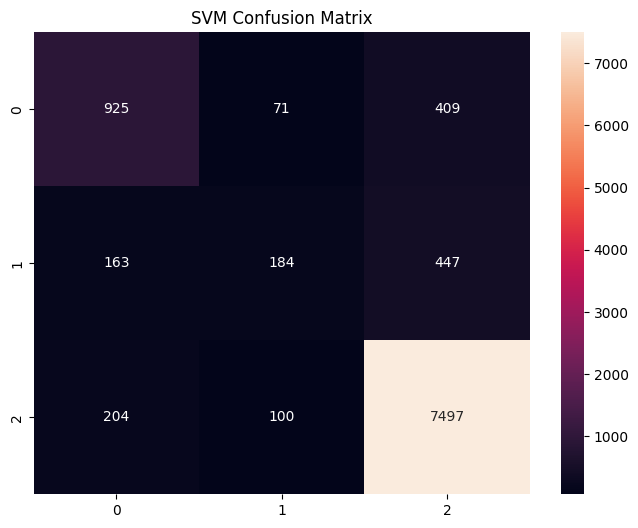

In [19]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "SVM Confusion Matrix"
)

plt.show()

Saving Model

In [20]:
joblib.dump(
    svm,
    "sentiment_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [21]:
print(df.shape)
print(df.columns.tolist())

(50000, 4)
['Score', 'Text', 'Sentiment', 'CleanText']


Compare Model

In [22]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

Naive Bayes Accuracy: 0.8164
SVM Accuracy: 0.8606


Classification Report

In [23]:
print(classification_report(y_test, nb_pred))
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    Negative       0.84      0.28      0.42      1405
     Neutral       0.67      0.00      0.01       794
    Positive       0.82      1.00      0.90      7801

    accuracy                           0.82     10000
   macro avg       0.78      0.43      0.44     10000
weighted avg       0.81      0.82      0.76     10000

              precision    recall  f1-score   support

    Negative       0.72      0.66      0.69      1405
     Neutral       0.52      0.23      0.32       794
    Positive       0.90      0.96      0.93      7801

    accuracy                           0.86     10000
   macro avg       0.71      0.62      0.64     10000
weighted avg       0.84      0.86      0.85     10000



Confusion Matrix

In [24]:
cm = confusion_matrix(y_test, svm_pred)

Sentiment Distribution Plot

<Axes: xlabel='Sentiment', ylabel='count'>

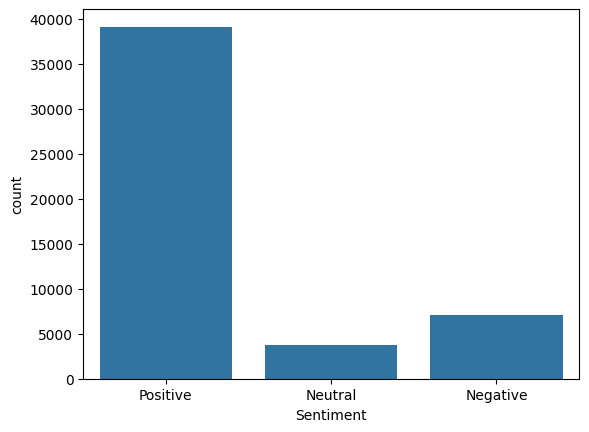

In [25]:
sns.countplot(x='Sentiment', data=df)

In [26]:
joblib.dump(svm, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']